## Taran's Contribution

### Tuning DCGAN

In [55]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Hyperparameters

### Increased to 20 epochs for more accurate image generation

In [69]:
import os
import torch
import random
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from collections import defaultdict

# Parameters
root_dir = "balanced_labeled_photos"
batch_size = 64
image_size = 64
samples_per_class = 5000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Load full dataset
full_dataset = ImageFolder(root=root_dir, transform=transform)

# Get class-wise indices
class_to_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_dataset.samples):
    class_to_indices[label].append(idx)

# Subset sampling: take 5000 from each class
balanced_indices = []
for label, indices in class_to_indices.items():
    if len(indices) < samples_per_class:
        raise ValueError(f"Class {label} has only {len(indices)} samples, need at least 5000")
    selected = random.sample(indices, samples_per_class)
    balanced_indices.extend(selected)

# Create balanced subset loader
balanced_subset = Subset(full_dataset, balanced_indices)
dataloader = DataLoader(balanced_subset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

## Generator

In [70]:
class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0),  # 1x1 → 4x4
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),    # 4x4 → 8x8
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),    # 8x8 → 16x16
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),     # 16x16 → 32x32
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),       # 32x32 → 64x64
            nn.Tanh()
        )
    
    def forward(self, z):
        return self.main(z)

## Discriminator

In [71]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0), nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)

## Training 

In [72]:
# Training Loop 
num_epochs = 20
latent_dim = 128
lr = 0.0002
beta1 = 0.4

generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))
criterion = nn.BCELoss()

fixed_noise = torch.randn(25, latent_dim, 1, 1, device=device)
os.makedirs("dcgan_outputs/tuned_images_balanced", exist_ok=True)

from torchvision.utils import make_grid, save_image
from tqdm import tqdm

for epoch in range(1, num_epochs + 1):
    loop = tqdm(dataloader, desc=f"Epoch {epoch}/{num_epochs}")
    for i, (imgs, _) in enumerate(loop):
        real_imgs = imgs.to(device)
        b_size = real_imgs.size(0)

        valid = torch.ones(b_size, device=device)
        fake = torch.zeros(b_size, device=device)

        # Train Generator
        z = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake_imgs = generator(z)
        g_loss = criterion(discriminator(fake_imgs), valid)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        # Train Discriminator
        real_loss = criterion(discriminator(real_imgs), valid)
        fake_loss = criterion(discriminator(fake_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        loop.set_postfix(G_Loss=g_loss.item(), D_Loss=d_loss.item())

    # Save sample images
    if epoch % 5 == 0:
        with torch.no_grad():
            gen_imgs = generator(fixed_noise).detach().cpu()
            grid = make_grid(gen_imgs, nrow=5, normalize=True)
            save_image(grid, f"dcgan_outputs/tuned_images_balanced/dcgan_epoch_{epoch}.png")

Epoch 20/20: 100%|████████████████████████████████████████| 391/391 [00:57<00:00,  6.82it/s, D_Loss=0.155, G_Loss=5.61]


In [73]:
# Save Tuned Generator and Discriminator
import torch
import os

# Define paths
save_dir = "dcgan_outputs/tuned_model"
os.makedirs(save_dir, exist_ok=True)

# Save generator and discriminator
torch.save(generator.state_dict(), os.path.join(save_dir, "dcgan_generator_tuned.pth"))
torch.save(discriminator.state_dict(), os.path.join(save_dir, "dcgan_discriminator_tuned.pth"))

print("Tuned DCGAN models saved successfully!")

Tuned DCGAN models saved successfully!


## Load the Tuned Generator Model

In [74]:
import torch
import os

# Define latent size and device
latent_dim = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reuse tuned Generator architecture
class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )
    def forward(self, z):
        return self.main(z)

# Load model
generator = Generator(latent_dim).to(device)
generator.load_state_dict(torch.load("dcgan_outputs/tuned_model/dcgan_generator_tuned.pth", map_location=device))
generator.eval()

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): Tanh()
  )
)

## Generate 100 Fake Images

In [75]:
from torchvision.utils import save_image
import os

os.makedirs("dcgan_outputs/tuned_fakes", exist_ok=True)

for i in range(100):
    z = torch.randn(1, latent_dim, 1, 1, device=device)
    with torch.no_grad():
        gen_img = generator(z).detach().cpu()
    img = (gen_img + 1) / 2  # from [-1, 1] → [0, 1]
    save_image(img, f"dcgan_outputs/tuned_fakes/fake_{i+1}.png")

## Load Real and Fake Images

In [76]:
from torchvision import transforms
from PIL import Image
import glob

# Recursive image loader
def load_images_from_folder(folder, max_images=100):
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: (x * 255).byte())  # → uint8
    ])
    images = []
    paths = glob.glob(os.path.join(folder, "**", "*.*"), recursive=True)
    for path in paths:
        if path.lower().endswith((".png", ".jpg", ".jpeg")):
            try:
                img = Image.open(path).convert("RGB")
                images.append(transform(img))
            except:
                continue
        if len(images) >= max_images:
            break
    return torch.stack(images)

# Load real and fake
real_images = load_images_from_folder("balanced_labeled_photos", max_images=100).to(device)
fake_images = load_images_from_folder("dcgan_outputs/tuned_fakes", max_images=100).to(device)

print(f"Loaded {real_images.size(0)} real and {fake_images.size(0)} fake images")

Loaded 100 real and 100 fake images


## Calculate IS and FID

In [78]:
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance

# Inception Score
print("\nCalculating Inception Score...")
is_metric = InceptionScore().to(device)
is_metric.update(fake_images)
is_score = is_metric.compute()
print(f"Inception Score (Tuned): {is_score[0]:.3f} ± {is_score[1]:.3f}")

# FID
print("\nCalculating FID...")
fid_metric = FrechetInceptionDistance(normalize=True).to(device)
fid_metric.update(real_images, real=True)
fid_metric.update(fake_images, real=False)
fid_score = fid_metric.compute()
print(f"FID Score (Tuned): {fid_score:.2f}")


Calculating Inception Score...
Inception Score (Tuned): 2.745 ± 0.483

Calculating FID...
FID Score (Tuned): 265.72


## Original vs Tuned Images (Side-by-Side)

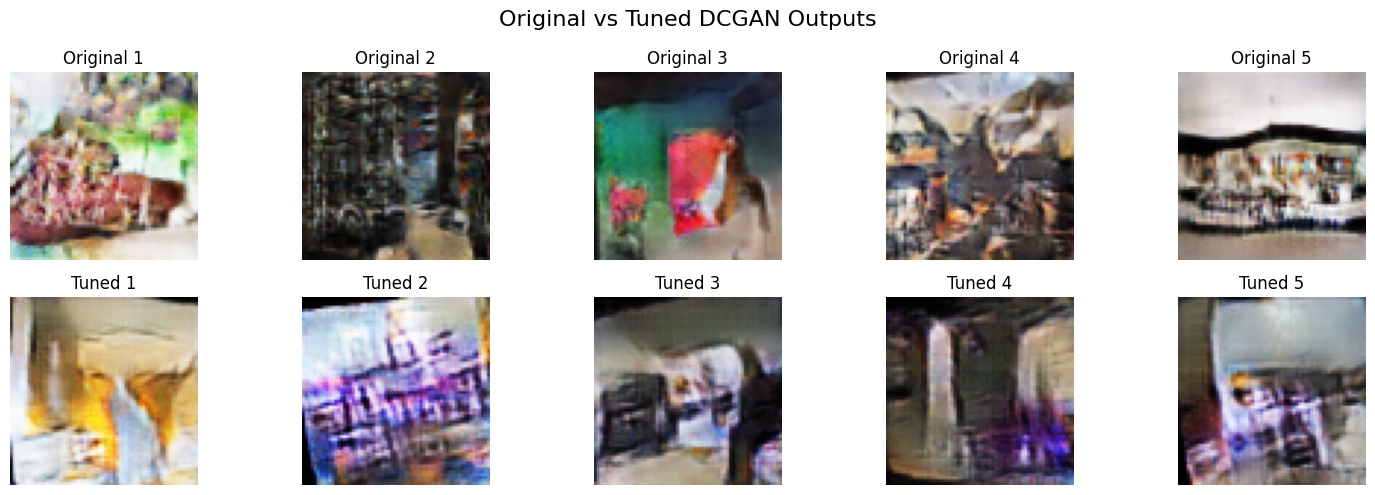

In [79]:
import matplotlib.pyplot as plt
from PIL import Image
import os

original_folder = "dcgan_outputs/generated_fakes"
tuned_folder = "dcgan_outputs/tuned_fakes"

fig, axes = plt.subplots(2, 5, figsize=(15, 5))
fig.suptitle("Original vs Tuned DCGAN Outputs", fontsize=16)

for i in range(5):
    # Load original
    orig_path = os.path.join(original_folder, f"dcgan_gen_{i+1}.png")
    orig_img = Image.open(orig_path)
    axes[0, i].imshow(orig_img)
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Original {i+1}")

    # Load tuned
    tuned_path = os.path.join(tuned_folder, f"fake_{i+1}.png")
    tuned_img = Image.open(tuned_path)
    axes[1, i].imshow(tuned_img)
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Tuned {i+1}")

plt.tight_layout()
plt.show()

### DCGAN Evaluation Comparison (Original vs Tuned)

| **Metric**           | **Original DCGAN**     | **Tuned DCGAN**        |
|----------------------|------------------------|-------------------------|
| **Inception Score**  | 2.969 ± 0.325          | 2.745 ± 0.483           |
| **FID Score**        | 268.21                 | 265.72                  |

---

### Interpretation:

- **FID improved** in the tuned model (lower is better), indicating closer resemblance to real image distribution.
- **Slight drop in Inception Score**, suggesting reduced diversity in image generation — possibly a tradeoff for better structure or quality.


### DCGAN Model Comparison: Original vs Tuned

| **Feature**           | **Original DCGAN**                    | **Tuned DCGAN Changes**                                          |
|-----------------------|----------------------------------------|------------------------------------------------------------------|
| **Generator Depth**   | Shallow (few conv layers)             | Deeper generator (more layers, better feature reuse)             |
| **Discriminator Depth** | Basic                               | Deeper discriminator                                             |
| **Latent Dim**        | 100                                   | 128 (more complex noise input)                                   |
| **Normalization**     | BatchNorm                             | Keep                           |
| **Activation**        | Tanh + LeakyReLU                      | Same, well-suited                                                |
| **Optimizer**         | Adam (`lr=0.0002`)                    | Adam (lower β₁ = 0.4 for better discriminator updates)           |
| **Output Saving**     | Add periodic sampling                 | Enhanced sampling grid saving                                    |
| **Training Epochs**   | 10                                    | 20  |

LLM PROMPTS
1. How can I tuned a simple DCGAN model to improve the quality of generated images, including architectural changes (like spectral normalization and dropout)
2. Can i do hyperparameter tuning (latent_dim, learning rate)??